In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 1000
categories = ['Vegetable', 'Dairy', 'Meat', 'Grain', 'Fruit']
data = {
    'Stock_Quantity': np.random.randint(50, 500, n_samples),
    'Sales_Volume': np.random.randint(10, 450, n_samples),
    'Days_to_Expire': np.random.randint(1, 15, n_samples),
    'Unit_Price': np.round(np.random.uniform(1.0, 15.0, n_samples), 2),
    'Inventory_Turnover_Rate': np.round(np.random.uniform(0.1, 1.5, n_samples), 2),
    'Category': np.random.choice(categories, n_samples)
}

df = pd.DataFrame(data)



In [ ]:
df.head()

,Stock_Quantity,Sales_Volume,Days_to_Expire,Unit_Price,Inventory_Turnover_Rate,Category
0,152,142,6,2.41,0.74,Dairy
1,485,294,12,10.69,0.66,Grain
2,398,397,7,1.87,0.52,Grain
3,320,147,5,8.13,0.19,Meat
4,156,193,11,14.95,0.42,Vegetable


In [ ]:
  # Simulate Waste_Quantity based on business logic
  df['Waste_Quantity'] = np.maximum(
      0,
      df['Stock_Quantity'] - df['Sales_Volume'] - (df['Inventory_Turnover_Rate'] * 10) - df['Days_to_Expire'] * np.random.uniform(1, 2)
  )

  # One-hot encode category
  df_encoded = pd.get_dummies(df, columns=['Category'])



In [ ]:
# Split features and target
X = df_encoded.drop('Waste_Quantity', axis=1)
y = df_encoded['Waste_Quantity']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

MAE: 5.73266151492604
RMSE: 8.647355475411857
R² Score: 0.9941739133917524


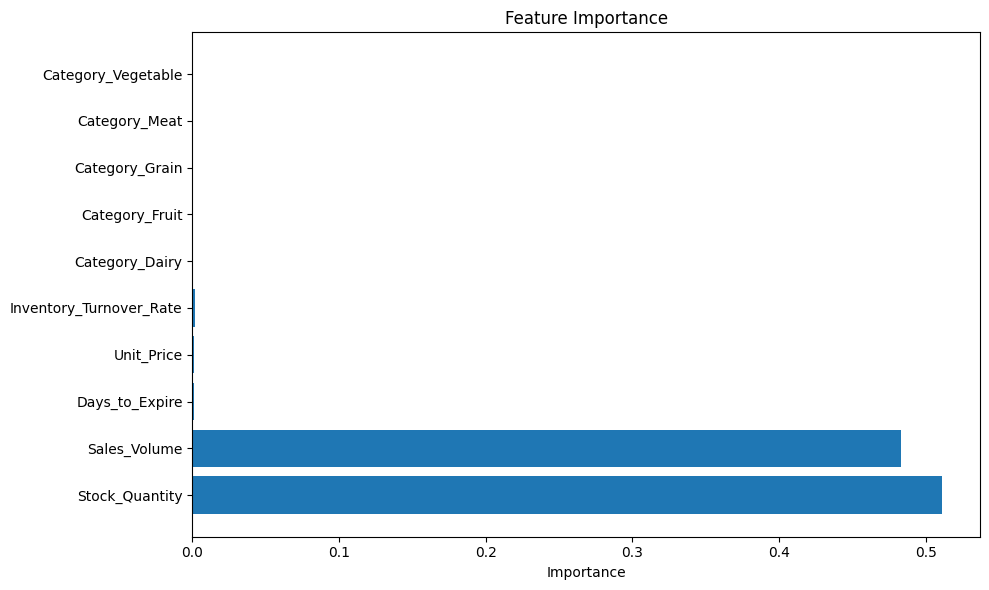

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_
feat_names = X.columns
plt.figure(figsize=(10,6))
plt.barh(feat_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


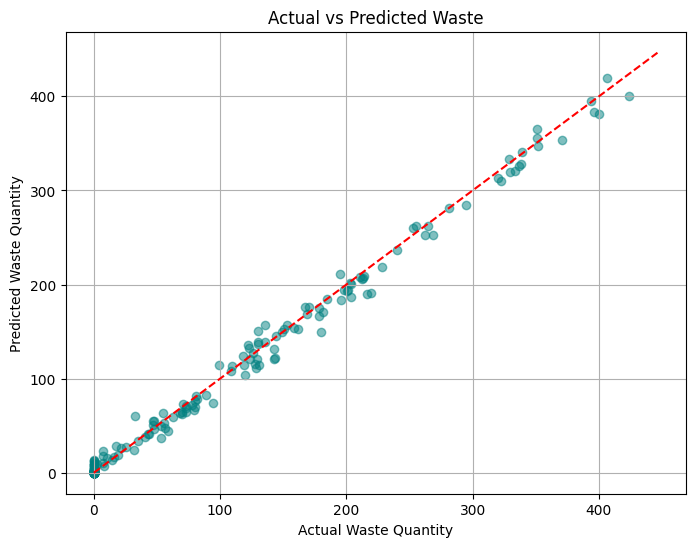

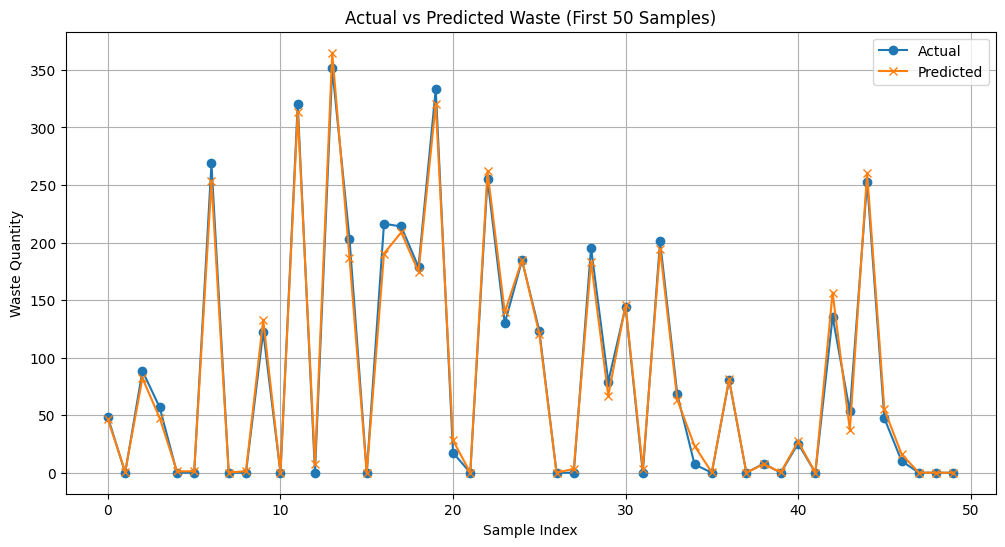

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel("Actual Waste Quantity")
plt.ylabel("Predicted Waste Quantity")
plt.title("Actual vs Predicted Waste")
plt.grid(True)
plt.show()

# Line plot for first 50 samples
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Actual vs Predicted Waste (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Waste Quantity")
plt.legend()
plt.grid(True)
plt.show()


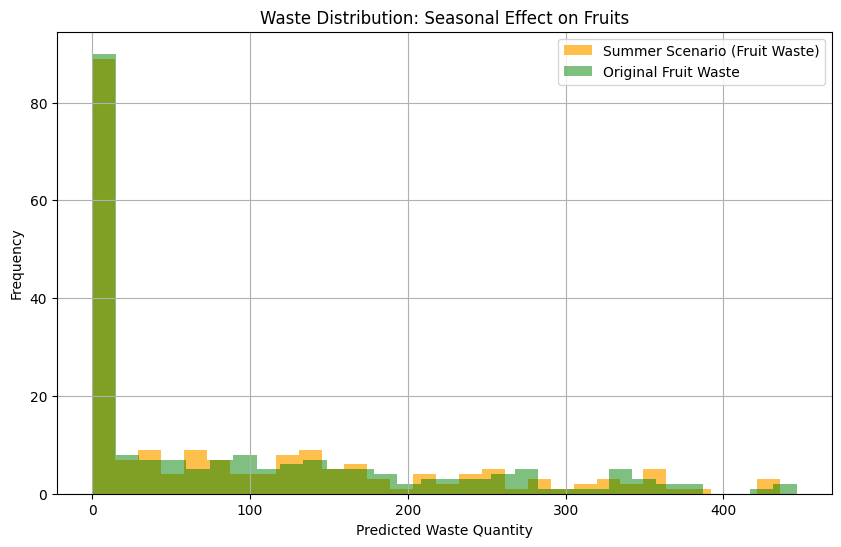

In [ ]:
# Simulate summer season with high fruit spoilage
summer_df = df[df['Category'] == 'Fruit'].copy()
summer_df['Days_to_Expire'] = summer_df['Days_to_Expire'] - 2  # spoil faster
summer_df['Inventory_Turnover_Rate'] = summer_df['Inventory_Turnover_Rate'] * 0.8  # slower usage

# One-hot encode again
summer_encoded = pd.get_dummies(summer_df, columns=['Category'])
summer_encoded = summer_encoded.reindex(columns=X.columns, fill_value=0)

# Predict on summer scenario
summer_preds = model.predict(summer_encoded)

# Compare old vs simulated predictions
plt.figure(figsize=(10,6))
plt.hist(summer_preds, bins=30, alpha=0.7, label='Summer Scenario (Fruit Waste)', color='orange')
plt.hist(df[df['Category'] == 'Fruit']['Waste_Quantity'], bins=30, alpha=0.5, label='Original Fruit Waste', color='green')
plt.title("Waste Distribution: Seasonal Effect on Fruits")
plt.xlabel("Predicted Waste Quantity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


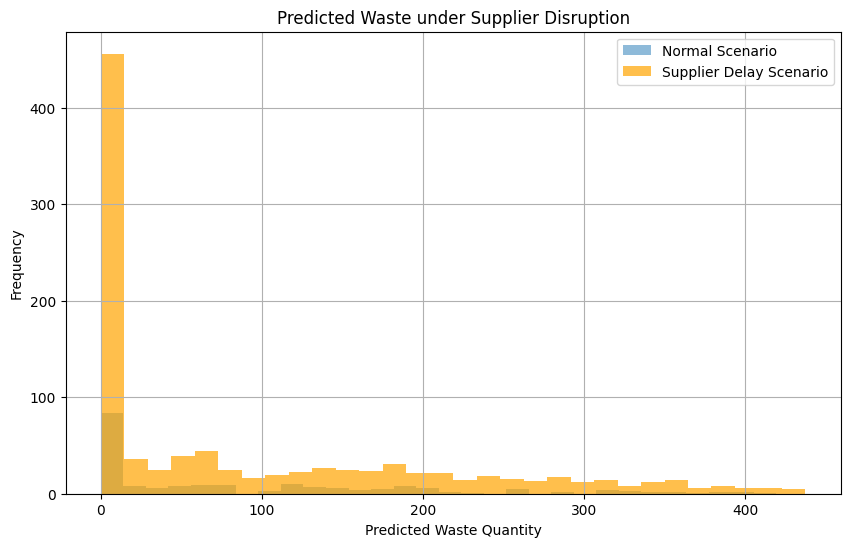

In [ ]:
# Simulate supplier delays
delay_df = df.copy()
delay_df['Days_to_Expire'] += 3  # more aging in warehouse
delay_df['Inventory_Turnover_Rate'] *= 0.7  # slower movement

delay_encoded = pd.get_dummies(delay_df, columns=['Category'])
delay_encoded = delay_encoded.reindex(columns=X.columns, fill_value=0)

delay_preds = model.predict(delay_encoded)

# Compare waste under normal vs delayed supply
plt.figure(figsize=(10,6))
plt.hist(y_pred, bins=30, alpha=0.5, label='Normal Scenario')
plt.hist(delay_preds, bins=30, alpha=0.7, label='Supplier Delay Scenario', color='orange')
plt.title("Predicted Waste under Supplier Disruption")
plt.xlabel("Predicted Waste Quantity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pickle

# Assuming your model is stored in a variable called `model`
with open('regression_waste_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")


Model saved successfully!
